# 15 — Weekly Forecast Analysis
## SunnyBest Retail Forecasting System

> **Purpose:** Read, explore and visualise the weekly unit forecasts generated by the model.  
> Run this notebook after `generate_weekly_forecast.py` to understand what the model is predicting.

| Section | What you see |
|---------|-------------|
| 1 | What weeks and models are in the forecast file |
| 2 | Forecast summary — total units per store |
| 3 | Forecast by category |
| 4 | Top 10 highest and lowest predicted products |
| 5 | Store × product heatmap |

---
## 0. Setup

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sqlalchemy import create_engine
from urllib.parse import quote_plus

plt.rcParams["figure.figsize"]    = (14, 5)
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
PALETTE = ["#4C72B0","#C44E52","#55A868","#DD8452","#8172B2","#64B5CD","#CCB974"]

FORECAST_PATH = "../data/outputs/weekly_forecasts.csv"

# DB connection — to enrich with product/store names
host     = "aws-1-eu-central-1.pooler.supabase.com"
port     = 5432
database = "postgres"
user     = "postgres.ogkdfmkybqtrsglcizzt"
password = quote_plus(os.getenv("SUPABASE_DB_PASSWORD", "Bonabosssfs01"))

engine = create_engine(
    f"postgresql+psycopg2://{user}:{password}@{host}:{port}/{database}",
    pool_pre_ping=True, pool_recycle=300
)

print("Setup complete")

Setup complete


---
## 1. Load Forecasts & Enrich with Names

In [14]:
# Load forecasts
df = pd.read_csv(FORECAST_PATH)
df["week_start"]     = pd.to_datetime(df["week_start"])
df["store_id"]       = df["store_id"].astype(str)
df["product_id"]     = pd.to_numeric(df["product_id"], errors="coerce").astype(int)
df["predicted_units"]= pd.to_numeric(df["predicted_units"], errors="coerce")

# Load dim tables for names
stores   = pd.read_sql("SELECT store_id::text, store_name, store_size, city, region FROM core.dim_stores", engine)
products = pd.read_sql("SELECT product_id, product_name, category, regular_price FROM core.dim_products", engine)
products["product_id"] = products["product_id"].astype(int)

# Enrich
df = df.merge(stores,   on="store_id",   how="left")
df = df.merge(products, on="product_id", how="left")

# Latest forecast week only
latest_week = df["week_start"].max()
fc = df[df["week_start"] == latest_week].copy()

print(f"Forecast week  : {latest_week.date()}")
print(f"Model used     : {fc['model_version'].iloc[0]}")
print(f"Predictions    : {len(fc):,}  ({fc['store_id'].nunique()} stores × {fc['product_id'].nunique()} products)")
print(f"Total predicted: {fc['predicted_units'].sum():,.0f} units")
print()
display(fc[["store_name","product_name","category","predicted_units","regular_price"]])

Forecast week  : 2026-05-11
Model used     : weekly_model_v3_calendar
Predictions    : 840  (7 stores × 120 products)
Total predicted: 12,525 units



,store_name,product_name,category,predicted_units,regular_price
1680,SunnyBest Benin Main,LG Televisions Model-120,Televisions,7.51,163694
1681,SunnyBest Benin Main,Tecno Mobile Model-199,Mobile Phones,16.78,208266
1682,SunnyBest Benin Main,Tecno Mobile Model-905,Mobile Phones,14.85,107221
1683,SunnyBest Benin Main,Infinix Mobile Model-847,Mobile Phones,20.27,224779
1684,SunnyBest Benin Main,Tecno Mobile Model-289,Mobile Phones,6.02,196730
...,...,...,...,...,...
2515,SunnyBest Ogwa,HP Laptops Model-171,Laptops & Computers,6.20,296615
2516,SunnyBest Ogwa,Apple Mobile Model-990,Mobile Phones,12.80,229089
2517,SunnyBest Ogwa,HP Laptops Model-833,Laptops & Computers,0.07,235765
2518,SunnyBest Ogwa,Huawei Network Model-306,Network Devices,3.97,63871


---
## 2. Forecast Summary by Store

> Which stores are expected to sell the most units this week?

,store_name,store_size,city,predicted_units,products
2,SunnyBest Benin Main,Large,Benin,2791.7,120
3,SunnyBest Ekpoma,Medium,Ekpoma,1927.1,120
1,SunnyBest Auchi,Medium,Auchi,1795.1,120
0,SunnyBest Agenebode,Small,Agenebode,1564.0,120
6,SunnyBest Ogwa,Small,Ogwa,1539.2,120
4,SunnyBest Igueben,Small,Igueben,1498.5,120
5,SunnyBest Irrua,Small,Irrua,1409.5,120


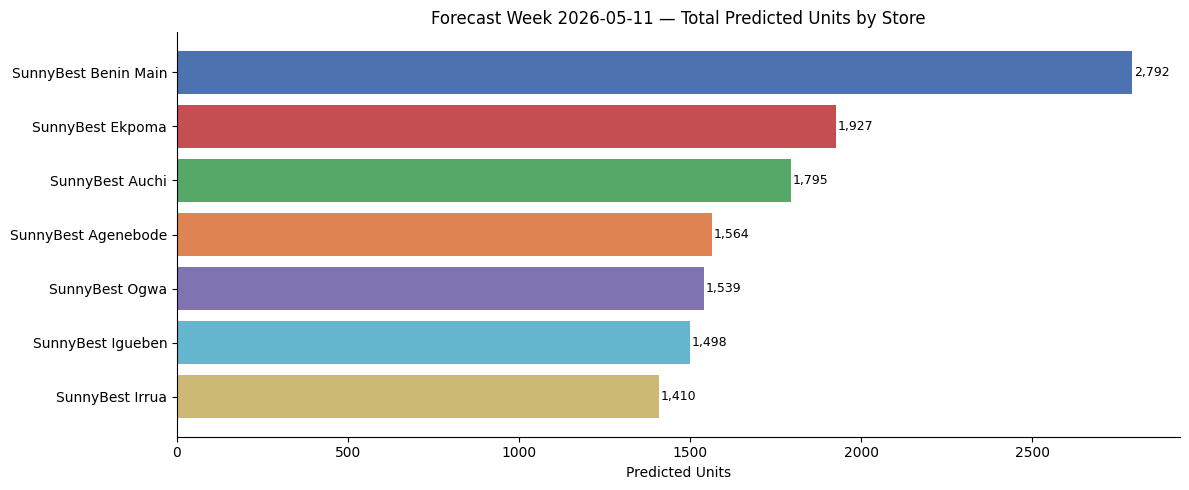

In [4]:
by_store = (fc.groupby(["store_name","store_size","city"])
              .agg(predicted_units=("predicted_units","sum"),
                   products       =("product_id","nunique"))
              .reset_index()
              .sort_values("predicted_units", ascending=False))

by_store["predicted_units"] = by_store["predicted_units"].round(1)
display(by_store)

fig, ax = plt.subplots(figsize=(12, 5))
colors = [PALETTE[i % len(PALETTE)] for i in range(len(by_store))]
ax.barh(by_store["store_name"][::-1], by_store["predicted_units"][::-1], color=colors[::-1])
ax.set_xlabel("Predicted Units")
ax.set_title(f"Forecast Week {latest_week.date()} — Total Predicted Units by Store")
for i, (_, row) in enumerate(by_store[::-1].iterrows()):
    ax.text(row["predicted_units"] + 5, i, f"{row['predicted_units']:,.0f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

---
## 3. Forecast by Category

> Which product categories drive the most volume this week?

,category,predicted_units,products,avg_price,predicted_revenue
7,Telecom Services,4720.0,5,5013.000000,23661410.0
0,Accessories,2141.9,10,12610.600000,27010644.0
6,Small Appliances,2040.3,17,22091.764706,45073165.0
3,Mobile Phones,1973.7,25,159590.680000,314982529.0
4,Network Devices,712.3,14,38479.714286,27410640.0
2,Laptops & Computers,558.8,19,269543.315789,150628891.0
8,Televisions,198.6,10,163227.700000,32412124.0
1,Air Conditioners,146.2,14,192599.428571,28156110.0
5,Refrigerators,33.3,6,236231.833333,7871245.0


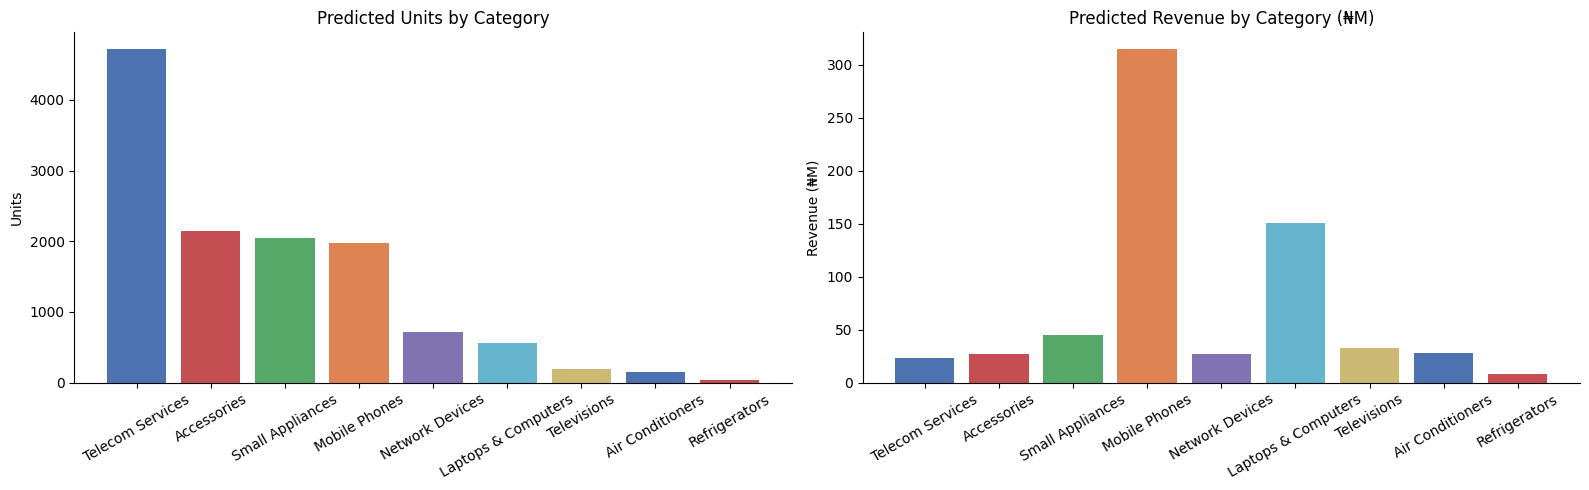

In [5]:
by_cat = (fc.groupby("category")
            .agg(predicted_units=("predicted_units","sum"),
                 products       =("product_id","nunique"),
                 avg_price      =("regular_price","mean"))
            .reset_index()
            .sort_values("predicted_units", ascending=False))

by_cat["predicted_revenue"] = (by_cat["predicted_units"] * by_cat["avg_price"]).round(0)
by_cat["predicted_units"]   = by_cat["predicted_units"].round(1)
display(by_cat)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(by_cat["category"], by_cat["predicted_units"],
            color=PALETTE[:len(by_cat)])
axes[0].set_title("Predicted Units by Category")
axes[0].set_ylabel("Units")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(by_cat["category"], by_cat["predicted_revenue"] / 1e6,
            color=PALETTE[:len(by_cat)])
axes[1].set_title("Predicted Revenue by Category (₦M)")
axes[1].set_ylabel("Revenue (₦M)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

---
## 4. Top 10 Highest & Lowest Predicted Products

> Highest — fast movers to ensure are well stocked.  
> Lowest — slow movers to watch for dead stock.

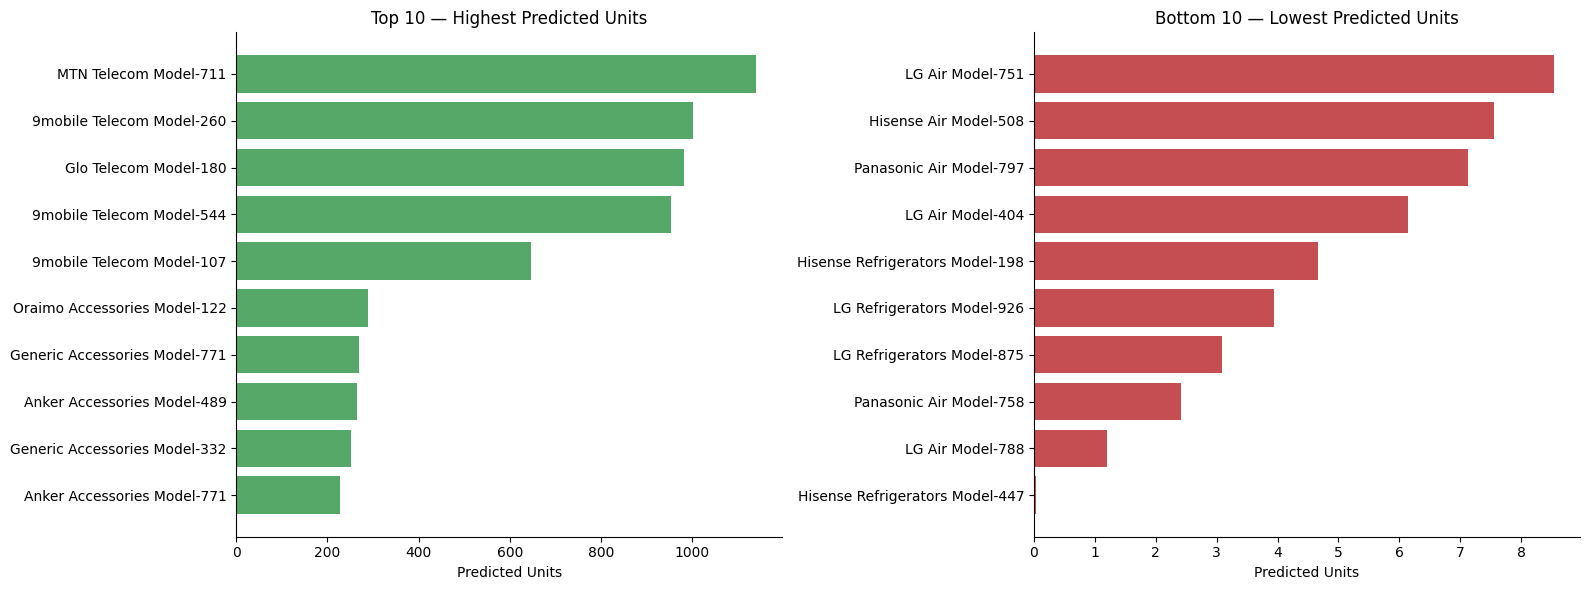

Top 10:


,product_name,category,regular_price,predicted_units
0,MTN Telecom Model-711,Telecom Services,7117,1139.90
1,9mobile Telecom Model-260,Telecom Services,690,1000.28
2,Glo Telecom Model-180,Telecom Services,8054,981.50
3,9mobile Telecom Model-544,Telecom Services,3641,952.06
4,9mobile Telecom Model-107,Telecom Services,5563,646.27
5,Oraimo Accessories Model-122,Accessories,11860,289.83
6,Generic Accessories Model-771,Accessories,15949,269.99
7,Anker Accessories Model-489,Accessories,5943,264.73
8,Generic Accessories Model-332,Accessories,15843,252.33
9,Anker Accessories Model-771,Accessories,15428,227.53



Bottom 10:


,product_name,category,regular_price,predicted_units
0,Hisense Refrigerators Model-447,Refrigerators,264013,0.04
1,LG Air Model-788,Air Conditioners,108888,1.20
2,Panasonic Air Model-758,Air Conditioners,293766,2.41
3,LG Refrigerators Model-875,Refrigerators,200627,3.08
4,LG Refrigerators Model-926,Refrigerators,319170,3.95
5,Hisense Refrigerators Model-198,Refrigerators,95486,4.66
6,LG Air Model-404,Air Conditioners,112677,6.14
7,Panasonic Air Model-797,Air Conditioners,214862,7.13
8,Hisense Air Model-508,Air Conditioners,156040,7.56
9,LG Air Model-751,Air Conditioners,223121,8.54


In [6]:
by_product = (fc.groupby(["product_id","product_name","category","regular_price"])
                .agg(predicted_units=("predicted_units","sum"))
                .reset_index()
                .sort_values("predicted_units", ascending=False))

top10    = by_product.head(10)
bottom10 = by_product.tail(10).sort_values("predicted_units")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top10["product_name"][::-1], top10["predicted_units"][::-1], color=PALETTE[2])
axes[0].set_title("Top 10 — Highest Predicted Units")
axes[0].set_xlabel("Predicted Units")

axes[1].barh(bottom10["product_name"], bottom10["predicted_units"], color=PALETTE[1])
axes[1].set_title("Bottom 10 — Lowest Predicted Units")
axes[1].set_xlabel("Predicted Units")

plt.tight_layout()
plt.show()

print("Top 10:")
display(top10[["product_name","category","regular_price","predicted_units"]].reset_index(drop=True))
print("\nBottom 10:")
display(bottom10[["product_name","category","regular_price","predicted_units"]].reset_index(drop=True))

---
## 5. Store × Category Heatmap

> Which store-category combinations drive the most volume?  
> Useful for deciding where to focus replenishment effort this week.

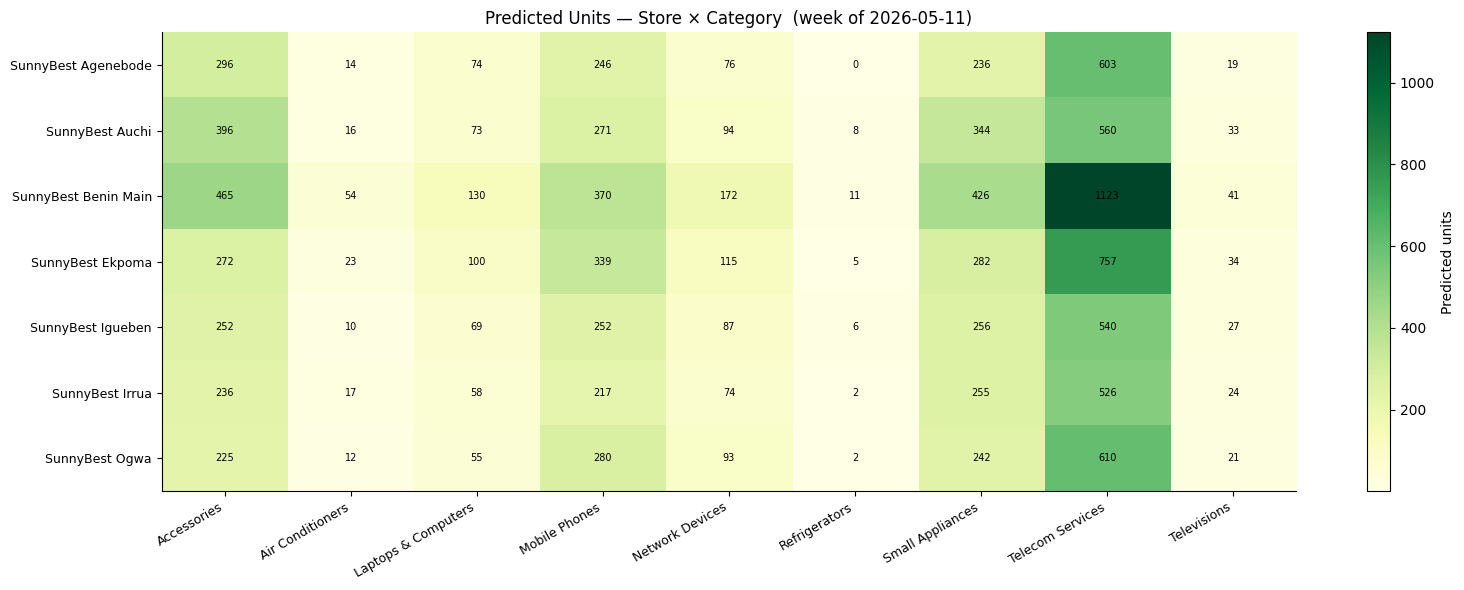

In [7]:
pivot = (fc.groupby(["store_name","category"])["predicted_units"]
           .sum()
           .round(1)
           .unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(pivot.values, cmap="YlGn", aspect="auto")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=30, ha="right", fontsize=9)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=9)
ax.set_title(f"Predicted Units — Store × Category  (week of {latest_week.date()})")
plt.colorbar(im, ax=ax, label="Predicted units")

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f"{pivot.values[i,j]:.0f}",
                ha="center", va="center", fontsize=7, color="black")

plt.tight_layout()
plt.show()

---
## 6. All Forecast Weeks (History)

> If you've run the forecast script multiple times, this shows all weeks side by side.

,week_start,model_version,total_predicted,rows
0,2026-03-30,weekly_model_v4_promotions,13571.0,840
1,2026-05-04,weekly_model_v3_calendar,12138.0,840
2,2026-05-11,weekly_model_v3_calendar,12525.0,840


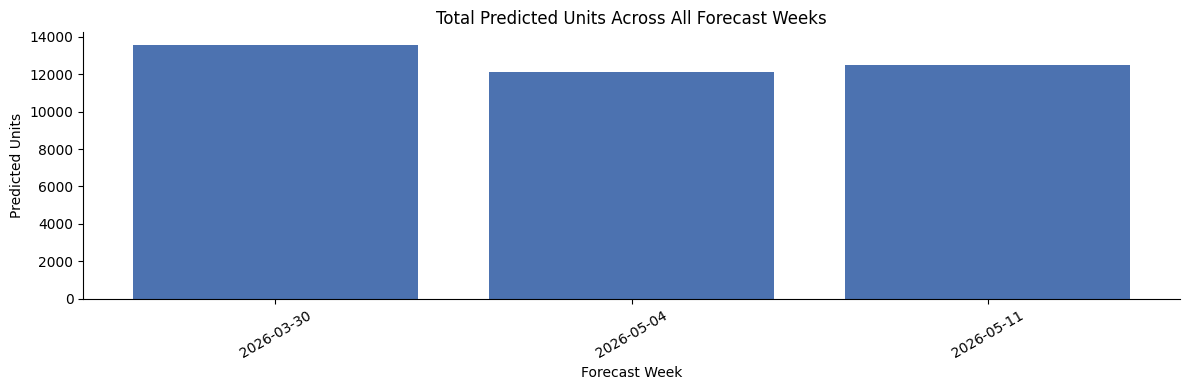

In [8]:
all_weeks = (df.groupby(["week_start","model_version"])
               .agg(total_predicted=("predicted_units","sum"),
                    rows=("product_id","count"))
               .reset_index())

all_weeks["total_predicted"] = all_weeks["total_predicted"].round(0)
display(all_weeks)

if len(all_weeks) > 1:
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(all_weeks["week_start"].dt.strftime("%Y-%m-%d"),
           all_weeks["total_predicted"], color=PALETTE[0])
    ax.set_title("Total Predicted Units Across All Forecast Weeks")
    ax.set_ylabel("Predicted Units")
    ax.set_xlabel("Forecast Week")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()
else:
    print("Only one forecast week so far — run the forecast script again next Saturday to build history.")

In [17]:
df_forecast = pd.read_csv("../data/outputs/weekly_forecasts.csv")

In [18]:
df_forecast["week_start"] = pd.to_datetime(df_forecast["week_start"])

may11 = df_forecast[df_forecast["week_start"] == "2026-05-11"] & df_forecast["model_version"]==weekly_model_v
may11

,week_start,store_id,product_id,predicted_units,forecast_created_at,model_version
1680,2026-05-11,1,1001,7.51,2026-05-10 00:00:00,weekly_model_v3_calendar
1681,2026-05-11,1,1002,16.78,2026-05-10 00:00:00,weekly_model_v3_calendar
1682,2026-05-11,1,1003,14.85,2026-05-10 00:00:00,weekly_model_v3_calendar
1683,2026-05-11,1,1004,20.27,2026-05-10 00:00:00,weekly_model_v3_calendar
1684,2026-05-11,1,1005,6.02,2026-05-10 00:00:00,weekly_model_v3_calendar
...,...,...,...,...,...,...
3355,2026-05-11,7,1116,5.46,2026-05-27 00:00:00,weekly_model_v3_calendar_2026_05
3356,2026-05-11,7,1117,12.18,2026-05-27 00:00:00,weekly_model_v3_calendar_2026_05
3357,2026-05-11,7,1118,0.01,2026-05-27 00:00:00,weekly_model_v3_calendar_2026_05
3358,2026-05-11,7,1119,3.97,2026-05-27 00:00:00,weekly_model_v3_calendar_2026_05
